In [6]:
df = pd.read_excel(r"D:\C drive files\Downloads\Lab Session Data (1) (1).xlsx", sheet_name=0)

print("Shape:", df.shape)
print("\nAll columns:")
for i, c in enumerate(df.columns):
    print(f"  [{i}] {repr(c)}  | dtype={df[c].dtype} | NaN={df[c].isnull().sum()} | unique={df[c].nunique(dropna=True)}")

print("\nFull first 5 rows (transposed view):")
print(df.head().T)

Shape: (10, 22)

All columns:
  [0] 'Customer'  | dtype=str | NaN=0 | unique=10
  [1] 'Candies (#)'  | dtype=int64 | NaN=0 | unique=9
  [2] 'Mangoes (Kg)'  | dtype=int64 | NaN=0 | unique=5
  [3] 'Milk Packets (#)'  | dtype=int64 | NaN=0 | unique=4
  [4] 'Payment (Rs)'  | dtype=int64 | NaN=0 | unique=10
  [5] 'Unnamed: 5'  | dtype=float64 | NaN=10 | unique=0
  [6] 'Unnamed: 6'  | dtype=float64 | NaN=10 | unique=0
  [7] 'Unnamed: 7'  | dtype=float64 | NaN=10 | unique=0
  [8] 'Unnamed: 8'  | dtype=float64 | NaN=10 | unique=0
  [9] 'Unnamed: 9'  | dtype=float64 | NaN=10 | unique=0
  [10] 'Unnamed: 10'  | dtype=float64 | NaN=10 | unique=0
  [11] 'Unnamed: 11'  | dtype=float64 | NaN=10 | unique=0
  [12] 'Unnamed: 12'  | dtype=float64 | NaN=10 | unique=0
  [13] 'Unnamed: 13'  | dtype=float64 | NaN=10 | unique=0
  [14] 'Unnamed: 14'  | dtype=float64 | NaN=10 | unique=0
  [15] 'Unnamed: 15'  | dtype=float64 | NaN=10 | unique=0
  [16] 'Unnamed: 16'  | dtype=float64 | NaN=10 | unique=0
  [17] 'Un

In [8]:
def prepare_data(df, target_column=None):
    """Project-specific prep for Lab Session Data.xlsx."""
    # Drop the fully-empty Unnamed columns and scratch columns
    drop_cols = [c for c in df.columns if str(c).startswith('Unnamed')
                 or str(c) in ['Customer', 'Candy', 'Mango', 'Milk']]
    df = df.drop(columns=drop_cols, errors='ignore')

    print(f"After dropping irrelevant columns: {df.columns.tolist()}")

    # Derive the target: High Value if Payment >= 250
    if 'Payment (Rs)' in df.columns:
        THRESHOLD = 250
        df['HighValue'] = (df['Payment (Rs)'] >= THRESHOLD).astype(int)
        target_column = 'HighValue'
        print(f"Derived target 'HighValue' from Payment (Rs) >= {THRESHOLD}")
    else:
        raise ValueError("Expected 'Payment (Rs)' column not found.")

    y = df[target_column].values.astype(int)
    X_df = df.drop(columns=[target_column])

    # Keep numeric features
    X_df = X_df.select_dtypes(include=[np.number]).fillna(0)

    print(f"Features: {X_df.columns.tolist()}")
    print(f"Number of features: {X_df.shape[1]}")
    print(f"Classes: {np.unique(y)}  Counts: {dict(zip(*np.unique(y, return_counts=True)))}")

    scaler = StandardScaler()
    X = scaler.fit_transform(X_df.values)
    return X, y, target_column, X_df.columns.tolist()

In [9]:
TARGET_COLUMN = None   # will be set to 'HighValue' inside prepare_data

LAB 08 — PERCEPTRON & NEURAL NETWORKS
LOADING DATASET
Shape: (10, 22)
Columns: ['Customer', 'Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)', 'Payment (Rs)', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Candy', 'Mango', 'Milk']

First 5 rows:
  Customer  Candies (#)  Mangoes (Kg)  Milk Packets (#)  Payment (Rs)  \
0      C_1           20             6                 2           386   
1      C_2           16             3                 6           289   
2      C_3           27             6                 2           393   
3      C_4           19             1                 2           110   
4      C_5           24             4                 2           280   

   Unnamed: 5  Unnamed: 6  Unnamed: 7  Unnamed: 8  Unnamed: 9  ...  \
0         NaN         NaN         NaN         NaN         NaN  ...   
1         NaN   

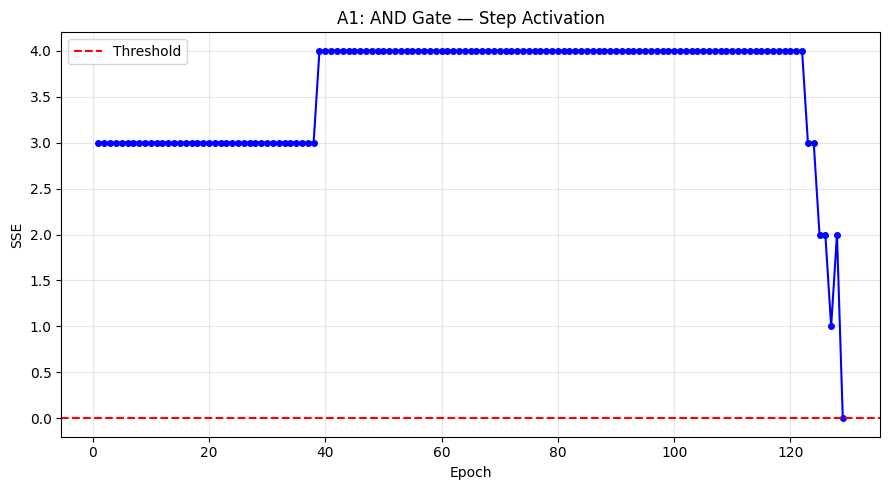

A3: AND Gate — Activation Comparison
  step            | epochs=  129 | SSE=0.000000
  bipolar_step    | epochs=   67 | SSE=0.000000
  sigmoid         | epochs= 4634 | SSE=0.001999
  relu            | epochs=  383 | SSE=0.001992


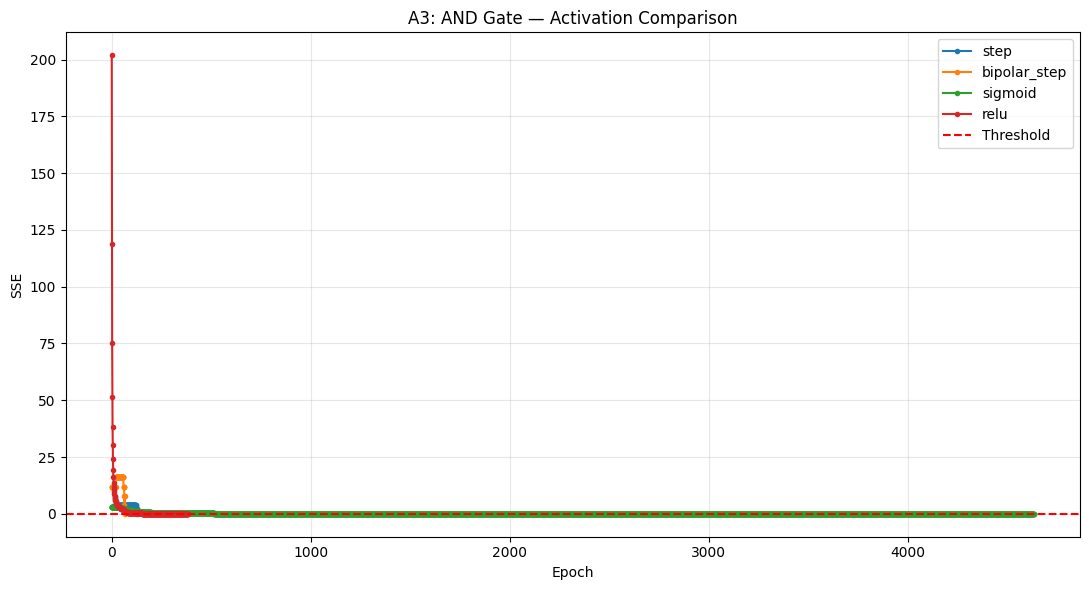

A4: AND Gate — Varying Learning Rate
  LR=0.1 -> epochs=67
  LR=0.2 -> epochs=36
  LR=0.3 -> epochs=22
  LR=0.4 -> epochs=22
  LR=0.5 -> epochs=19
  LR=0.6 -> epochs=18
  LR=0.7 -> epochs=14
  LR=0.8 -> epochs=13
  LR=0.9 -> epochs=12
  LR=1.0 -> epochs=13


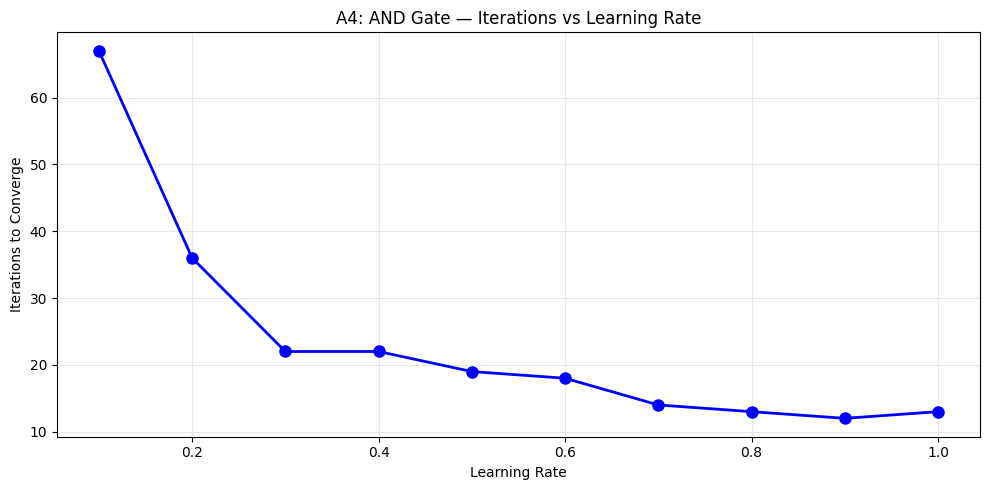

A5: XOR Gate
  -- Single perceptron on XOR (should FAIL) --
    step            | ep=1000 | SSE=3.000000 | Conv=False
    bipolar_step    | ep=1000 | SSE=2.000000 | Conv=False
    sigmoid         | ep=1000 | SSE=1.000267 | Conv=False
    relu            | ep=1000 | SSE=1.004155 | Conv=False
  -- 2-layer MLP on XOR --
    Converged at epoch 5577, SSE = 0.002000


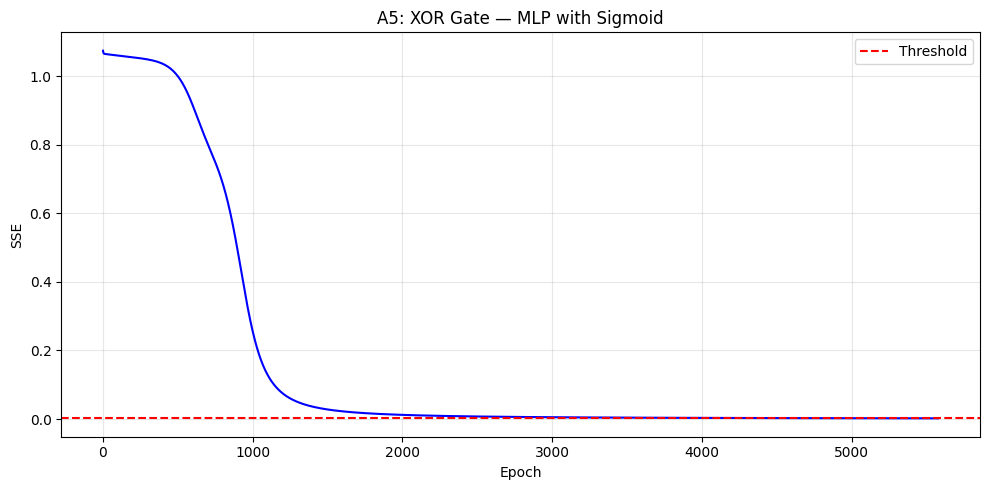

A6: Project Data Classification
  n_samples = 10, classes = [0 1], counts = [4 6]
  Converged at epoch 291 (SSE=0.001996)
  Epochs: 291, SSE: 0.001996
  Train accuracy: 100.00%
  Test accuracy:  100.00%


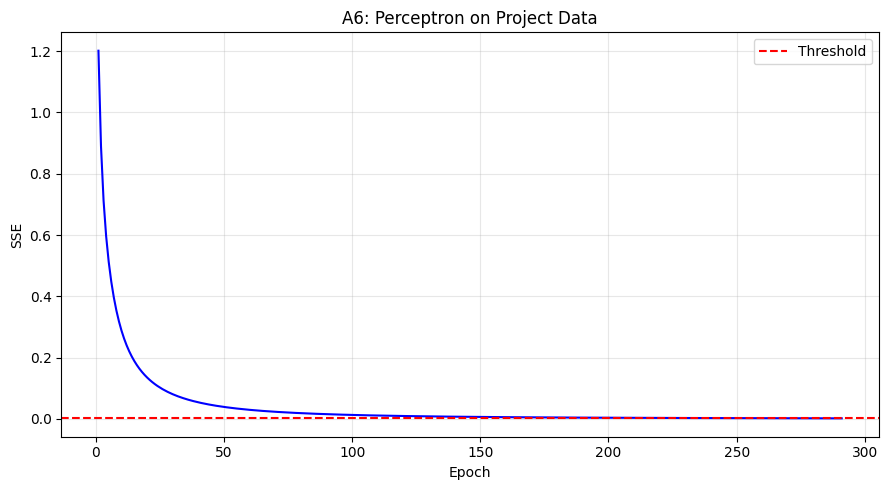

A7: Perceptron vs Pseudo-Inverse
  Pseudo-Inverse test accuracy: 66.67%
  Perceptron  test accuracy:    66.67% (epochs=113)
A8: Backprop MLP — AND Gate
  Epochs: 3166, SSE: 0.002000
    In [0 0] -> T=0, Pred=0.0007
    In [0 1] -> T=0, Pred=0.0197
    In [1 0] -> T=0, Pred=0.0197
    In [1 1] -> T=1, Pred=0.9651


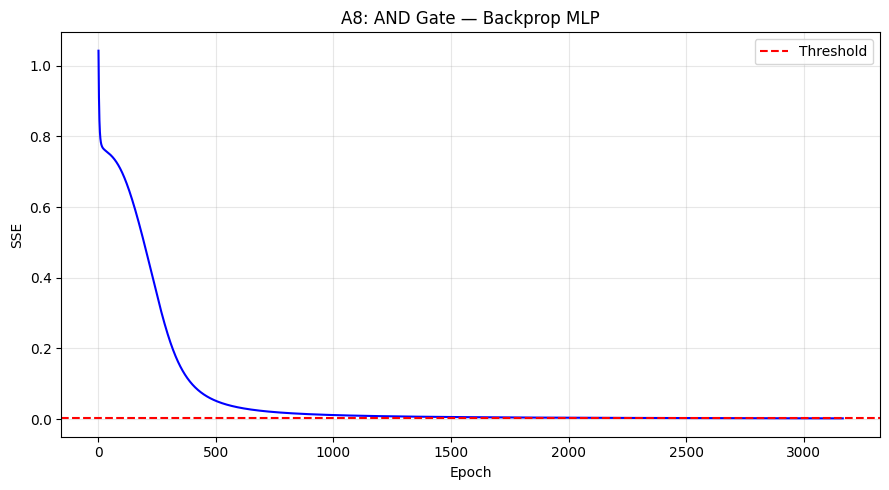

A9: Backprop MLP — XOR Gate
  Epochs: 7704, SSE: 0.002000
    In [0 0] -> T=0, Pred=0.0193
    In [0 1] -> T=1, Pred=0.9788
    In [1 0] -> T=1, Pred=0.9787
    In [1 1] -> T=0, Pred=0.0269


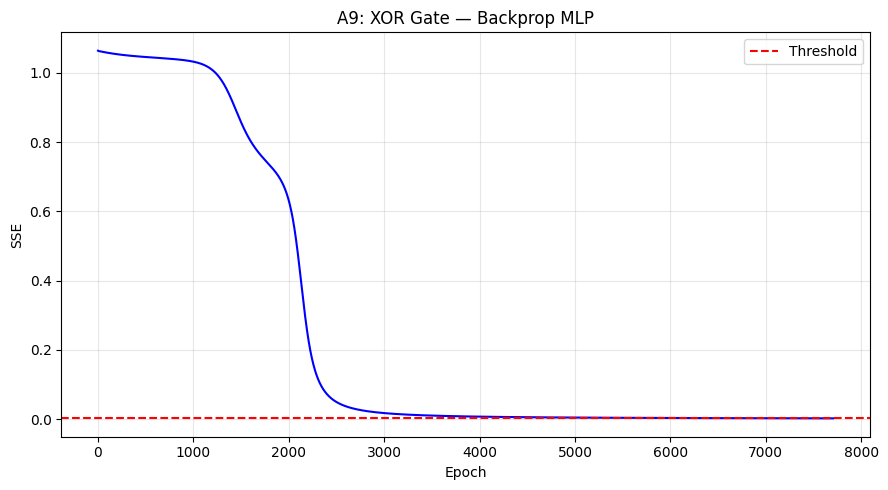

A10: AND Gate — 2 Output Nodes
  Converged at epoch 9, SSE = 0.000000
    In [0 0] -> T=[1 0], Pred=[1 0]
    In [0 1] -> T=[1 0], Pred=[1 0]
    In [1 0] -> T=[1 0], Pred=[1 0]
    In [1 1] -> T=[0 1], Pred=[0 1]


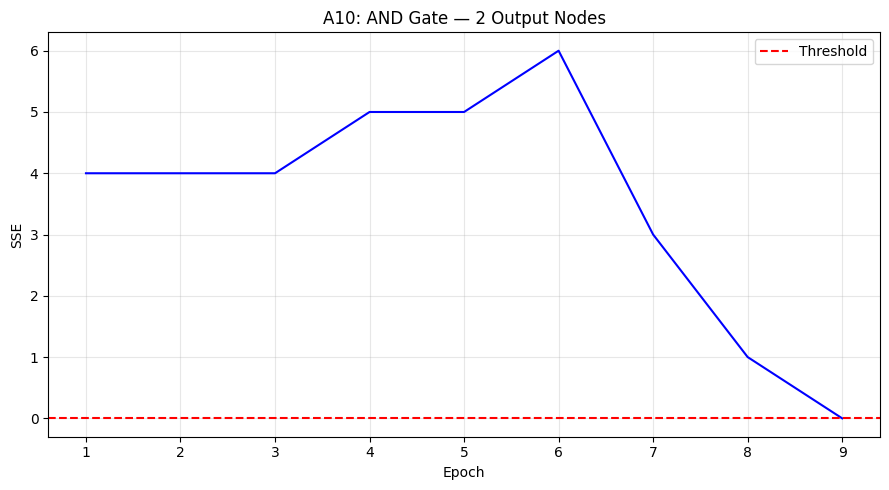

A11: MLPClassifier (AND & XOR)
  -- AND --
    Iter: 74, Loss: 0.025503, Preds: [0 0 0 1]
  -- XOR (patched: lbfgs) --
    Iter: 108, Loss: 0.008834, Preds: [0 1 1 0]
A12: MLPClassifier on Project Data
  Iter: 60, Loss: 0.020492, Acc: 66.67%
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3

O1: LR vs Activations (Sigmoid vs ReLU)
  sigmoid: [1000, 1000, 753, 559, 443, 365, 310, 268, 236, 210]
  relu: [180, 80, 46, 31, 20, 13, 1000, 8, 257, 6]


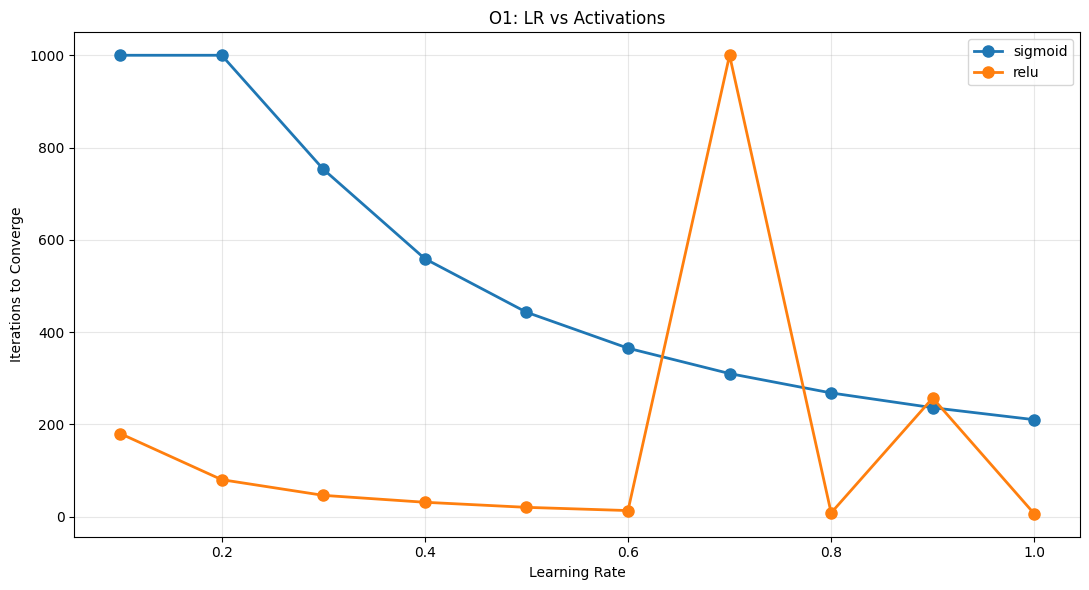

In [2]:
# =============================================================================
# LAB 08 - PERCEPTRON & NEURAL NETWORKS - FINAL WORKING VERSION
# Dataset: Lab Session Data (1) (1).xlsx
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

FILE_PATH = r"D:\C drive files\Downloads\Lab Session Data (1) (1).xlsx"
SHEET_NAME = 0
np.random.seed(42)
plt.close('all')


# =============================================================================
# ACTIVATION FUNCTIONS
# =============================================================================
def step_activation(y):              return 1 if y > 0 else 0
def bipolar_step_activation(y):      return 1 if y > 0 else (-1 if y < 0 else 0)
def sigmoid_activation(y):
    y = np.clip(y, -500, 500); return 1.0 / (1.0 + np.exp(-y))
def tanh_activation(y):              return float(np.tanh(y))
def relu_activation(y):              return max(0.0, float(y))
def leaky_relu_activation(y, a=0.01):
    y = float(y); return y if y > 0 else a * y

def summation_unit(x, w):            return float(np.dot(w, x))
def calculate_error(t, p):
    return float(np.sum((np.array(t, float) - np.array(p, float)) ** 2))


# =============================================================================
# PERCEPTRON CLASS
# =============================================================================
class Perceptron:
    def __init__(self, n_inputs, learning_rate=0.05, activation='step',
                 initial_weights=None, activation_alpha=0.01):
        self.n_inputs = n_inputs
        self.learning_rate = learning_rate
        self.activation_name = activation
        self.activation_alpha = activation_alpha
        if initial_weights is not None:
            self.weights = np.array(initial_weights, dtype=float)
        else:
            self.weights = np.random.uniform(-0.05, 0.05, n_inputs + 1)
        self._set_activation()

    def _set_activation(self):
        m = {'step': step_activation, 'bipolar_step': bipolar_step_activation,
             'sigmoid': sigmoid_activation, 'tanh': tanh_activation,
             'relu': relu_activation,
             'leaky_relu': lambda y: leaky_relu_activation(y, self.activation_alpha)}
        self.activation_function = m[self.activation_name]

    def predict(self, inputs):
        xb = np.insert(np.asarray(inputs, float), 0, 1)
        return float(self.activation_function(summation_unit(xb, self.weights)))

    def predict_batch(self, X):
        return np.array([self.predict(x) for x in X])

    def train(self, X, y, max_epochs=1000, convergence_threshold=0.002, verbose=False):
        X = np.array(X, float); y = np.array(y, float).ravel()
        errors = []
        for epoch in range(max_epochs):
            for i in range(len(X)):
                pred = self.predict(X[i])
                err = float(y[i] - pred)
                xb = np.insert(X[i], 0, 1)
                self.weights += self.learning_rate * err * xb
            sse = calculate_error(y, self.predict_batch(X))
            errors.append(sse)
            if sse <= convergence_threshold:
                if verbose:
                    print(f"  Converged at epoch {epoch+1} (SSE={sse:.6f})")
                return epoch + 1, errors
        return max_epochs, errors


# =============================================================================
# LOAD + PREPARE DATA
# =============================================================================
def load_dataset():
    print("LOADING DATASET")
    df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"\nFirst 5 rows:\n{df.head()}")
    return df


def prepare_data(df):
    """Dataset-specific prep. Derives HighValue target from Payment."""
    drop_cols = [c for c in df.columns if str(c).startswith('Unnamed')
                 or str(c) in ['Customer', 'Candy', 'Mango', 'Milk']]
    df = df.drop(columns=drop_cols, errors='ignore')

    print(f"Clean columns: {df.columns.tolist()}")

    if 'Payment (Rs)' not in df.columns:
        raise ValueError("Payment (Rs) column missing.")

    THRESHOLD = 250
    df['HighValue'] = (df['Payment (Rs)'] >= THRESHOLD).astype(int)
    print(f"Derived 'HighValue' from Payment (Rs) >= {THRESHOLD}")

    y = df['HighValue'].values.astype(int)
    X_df = df.drop(columns=['HighValue']).select_dtypes(include=[np.number]).fillna(0)

    print(f"Features: {X_df.columns.tolist()}")
    print(f"#features: {X_df.shape[1]}")
    print(f"Classes: {np.unique(y)}  Counts: {dict(zip(*np.unique(y, return_counts=True)))}")

    X = StandardScaler().fit_transform(X_df.values)
    return X, y, 'HighValue', X_df.columns.tolist()


# =============================================================================
# A1: AND Gate — Step
# =============================================================================
def experiment_a1():
    print("A1: AND Gate — Step Activation")
    X = np.array([[0,0],[0,1],[1,0],[1,1]]); y = np.array([0,0,0,1])
    init_w = [10, 0.2, -0.75]
    p = Perceptron(2, learning_rate=0.05, activation='step', initial_weights=init_w)
    ep, err = p.train(X, y, max_epochs=1000, convergence_threshold=0.002, verbose=True)
    print(f"  Final weights: {p.weights.round(4)}")
    print(f"  Epochs: {ep}, SSE: {err[-1]:.6f}, Preds: {p.predict_batch(X)}")
    plt.figure(figsize=(9,5))
    plt.plot(range(1, len(err)+1), err, 'b-o', ms=4)
    plt.axhline(0.002, color='r', ls='--', label='Threshold')
    plt.xlabel('Epoch'); plt.ylabel('SSE')
    plt.title('A1: AND Gate — Step Activation')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('a1_and_step.png', dpi=150); plt.show(); plt.close()
    return ep, err


# =============================================================================
# A3: Activation Comparison (PATCHED)
# =============================================================================
def experiment_a3():
    print("A3: AND Gate — Activation Comparison")
    X = np.array([[0,0],[0,1],[1,0],[1,1]])
    y = np.array([0,0,0,1])
    init_w = [10, 0.2, -0.75]
    acts = ['step','bipolar_step','sigmoid','relu']
    results = {}

    for a in acts:
        # Bipolar step needs {−1, +1} targets
        if a == 'bipolar_step':
            y_use = np.where(y == 0, -1, 1)
        else:
            y_use = y

        # Sigmoid needs more epochs
        max_ep = 5000 if a == 'sigmoid' else 1000

        p = Perceptron(2, learning_rate=0.05, activation=a, initial_weights=init_w)
        ep, err = p.train(X, y_use, max_epochs=max_ep, convergence_threshold=0.002)
        results[a] = {'epochs': ep, 'errors': err, 'sse': err[-1]}
        print(f"  {a:15s} | epochs={ep:5d} | SSE={err[-1]:.6f}")

    plt.figure(figsize=(11,6))
    for a in acts:
        plt.plot(range(1, len(results[a]['errors'])+1), results[a]['errors'],
                 marker='o', ms=3, label=a)
    plt.axhline(0.002, color='r', ls='--', label='Threshold')
    plt.xlabel('Epoch'); plt.ylabel('SSE')
    plt.title('A3: AND Gate — Activation Comparison')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('a3_and_activations.png', dpi=150); plt.show(); plt.close()
    return results


# =============================================================================
# A4: Vary Learning Rate
# =============================================================================
def experiment_a4():
    print("A4: AND Gate — Varying Learning Rate")
    X = np.array([[0,0],[0,1],[1,0],[1,1]]); y = np.array([0,0,0,1])
    init_w = [10, 0.2, -0.75]
    lrs = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]; eps = []
    for lr in lrs:
        p = Perceptron(2, learning_rate=lr, activation='step', initial_weights=init_w)
        ep, _ = p.train(X, y, max_epochs=1000, convergence_threshold=0.002)
        eps.append(ep); print(f"  LR={lr:.1f} -> epochs={ep}")
    plt.figure(figsize=(10,5))
    plt.plot(lrs, eps, 'b-o', ms=8, lw=2)
    plt.xlabel('Learning Rate'); plt.ylabel('Iterations to Converge')
    plt.title('A4: AND Gate — Iterations vs Learning Rate')
    plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('a4_and_lr.png', dpi=150); plt.show(); plt.close()
    return dict(zip(lrs, eps))


# =============================================================================
# A5: XOR Gate
# =============================================================================
def experiment_a5():
    print("A5: XOR Gate")
    X = np.array([[0,0],[0,1],[1,0],[1,1]]); y = np.array([0,1,1,0])
    init_w = [10, 0.2, -0.75]
    print("  -- Single perceptron on XOR (should FAIL) --")
    for a in ['step','bipolar_step','sigmoid','relu']:
        p = Perceptron(2, learning_rate=0.05, activation=a, initial_weights=init_w)
        ep, err = p.train(X, y, max_epochs=1000, convergence_threshold=0.002)
        print(f"    {a:15s} | ep={ep:4d} | SSE={err[-1]:.6f} | Conv={err[-1]<=0.002}")
    print("  -- 2-layer MLP on XOR --")
    return train_xor_mlp(X, y)


def train_xor_mlp(X, y, lr=0.5, hidden=4, max_epochs=20000, thresh=0.002):
    np.random.seed(42)
    W1 = np.random.uniform(-0.5, 0.5, (hidden, 3))
    W2 = np.random.uniform(-0.5, 0.5, (1, hidden + 1))
    sig = lambda x: 1/(1+np.exp(-np.clip(x,-500,500)))
    dsig = lambda x: (lambda s: s*(1-s))(sig(x))
    errors, conv_ep = [], None
    for epoch in range(max_epochs):
        total = 0.0
        for i in range(len(X)):
            xb = np.insert(X[i], 0, 1)
            h_in = np.dot(W1, xb); h = sig(h_in)
            hb = np.insert(h, 0, 1)
            o_in = np.dot(W2, hb); o = float(sig(o_in)[0])
            err = float(y[i] - o); total += err**2
            d_o = err * float(dsig(o_in)[0])
            d_h = dsig(h_in) * (W2[0,1:] * d_o)
            W2 += lr * d_o * hb
            for j in range(hidden): W1[j] += lr * d_h[j] * xb
        errors.append(total)
        if total <= thresh:
            conv_ep = epoch + 1
            print(f"    Converged at epoch {conv_ep}, SSE = {total:.6f}")
            break
    if conv_ep is None:
        print(f"    Did NOT converge in {max_epochs} epochs. SSE = {errors[-1]:.6f}")
    plt.figure(figsize=(10,5))
    plt.plot(range(1, len(errors)+1), errors, 'b-')
    plt.axhline(thresh, color='r', ls='--', label='Threshold')
    plt.xlabel('Epoch'); plt.ylabel('SSE')
    plt.title('A5: XOR Gate — MLP with Sigmoid')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('a5_xor.png', dpi=150); plt.show(); plt.close()
    return len(errors), errors


# =============================================================================
# A6: Project Data Classification
# =============================================================================
def experiment_a6(X, y):
    print("A6: Project Data Classification")
    n = len(y)
    print(f"  n_samples = {n}, classes = {np.unique(y)}, "
          f"counts = {np.bincount(y)}")
    if n < 10:
        print("  [SKIP] Not enough samples."); return None, None, 0, 0

    unique, counts = np.unique(y, return_counts=True)
    strat = y if (len(unique) == 2 and counts.min() >= 2) else None

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=strat)

    p = Perceptron(X_tr.shape[1], learning_rate=0.1, activation='sigmoid')
    ep, err = p.train(X_tr, y_tr, max_epochs=1000,
                      convergence_threshold=0.002, verbose=True)

    preds_tr = (p.predict_batch(X_tr) >= 0.5).astype(int).ravel()
    preds_te = (p.predict_batch(X_te) >= 0.5).astype(int).ravel()
    acc_tr = accuracy_score(y_tr.ravel(), preds_tr) * 100
    acc_te = accuracy_score(y_te.ravel(), preds_te) * 100

    print(f"  Epochs: {ep}, SSE: {err[-1]:.6f}")
    print(f"  Train accuracy: {acc_tr:.2f}%")
    print(f"  Test accuracy:  {acc_te:.2f}%")

    plt.figure(figsize=(9,5))
    plt.plot(range(1, len(err)+1), err, 'b-')
    plt.axhline(0.002, color='r', ls='--', label='Threshold')
    plt.xlabel('Epoch'); plt.ylabel('SSE')
    plt.title('A6: Perceptron on Project Data')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('a6_customer.png', dpi=150); plt.show(); plt.close()
    return ep, err, acc_tr, acc_te


# =============================================================================
# A7: Perceptron vs Pseudo-Inverse
# =============================================================================
def experiment_a7(X, y):
    print("A7: Perceptron vs Pseudo-Inverse")
    if len(y) < 10:
        print("  [SKIP] Not enough samples."); return None, None
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

    Xb = np.insert(X_tr, 0, 1, axis=1)
    w_pinv = np.dot(np.linalg.pinv(Xb), y_tr)
    Xteb = np.insert(X_te, 0, 1, axis=1)
    pinv_pred = (np.dot(Xteb, w_pinv) >= 0.5).astype(int).ravel()
    pinv_acc = accuracy_score(y_te.ravel(), pinv_pred) * 100

    p = Perceptron(X_tr.shape[1], learning_rate=0.1, activation='sigmoid')
    ep, _ = p.train(X_tr, y_tr, max_epochs=1000, convergence_threshold=0.002)
    perc_pred = (p.predict_batch(X_te) >= 0.5).astype(int).ravel()
    perc_acc = accuracy_score(y_te.ravel(), perc_pred) * 100

    print(f"  Pseudo-Inverse test accuracy: {pinv_acc:.2f}%")
    print(f"  Perceptron  test accuracy:    {perc_acc:.2f}% (epochs={ep})")
    return pinv_acc, perc_acc


# =============================================================================
# A8/A9: Backprop MLP
# =============================================================================
class BackpropMLP:
    def __init__(self, n_in, n_hid, n_out, lr=0.05):
        self.lr = lr
        self.W1 = np.random.uniform(-0.05, 0.05, (n_hid, n_in+1))
        self.W2 = np.random.uniform(-0.05, 0.05, (n_out, n_hid+1))
    def _sig(self, x): return 1/(1+np.exp(-np.clip(x,-500,500)))
    def _dsig(self, x): s = self._sig(x); return s*(1-s)
    def forward(self, x):
        xb = np.insert(x, 0, 1)
        self.h_in = np.dot(self.W1, xb); self.h_out = self._sig(self.h_in)
        hb = np.insert(self.h_out, 0, 1)
        self.o_in = np.dot(self.W2, hb); self.o_out = self._sig(self.o_in)
        return self.o_out
    def train(self, X, y, max_epochs=1000, thresh=0.002):
        errors = []
        for epoch in range(max_epochs):
            total = 0.0
            for i in range(len(X)):
                o = float(self.forward(X[i])[0])
                err = float(y[i] - o); total += err**2
                d_o = err * float(self._dsig(self.o_in)[0])
                hb = np.insert(self.h_out, 0, 1)
                d_h = self._dsig(self.h_in) * (self.W2[0,1:] * d_o)
                self.W2 += self.lr * d_o * hb
                xb = np.insert(X[i], 0, 1)
                for j in range(self.W1.shape[0]):
                    self.W1[j] += self.lr * d_h[j] * xb
            errors.append(total)
            if total <= thresh:
                return epoch + 1, errors
        return max_epochs, errors


def experiment_a8():
    # PATCH: lr=0.5, 20000 epochs
    print("A8: Backprop MLP — AND Gate")
    X = np.array([[0,0],[0,1],[1,0],[1,1]]); y = np.array([0,0,0,1])
    nn = BackpropMLP(2, 2, 1, lr=0.5)
    ep, err = nn.train(X, y, max_epochs=20000, thresh=0.002)
    print(f"  Epochs: {ep}, SSE: {err[-1]:.6f}")
    for i, x in enumerate(X):
        print(f"    In {x} -> T={y[i]}, Pred={float(nn.forward(x)[0]):.4f}")
    plt.figure(figsize=(9,5))
    plt.plot(range(1, len(err)+1), err, 'b-')
    plt.axhline(0.002, color='r', ls='--', label='Threshold')
    plt.xlabel('Epoch'); plt.ylabel('SSE')
    plt.title('A8: AND Gate — Backprop MLP')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('a8_and_bp.png', dpi=150); plt.show(); plt.close()
    return ep, err


def experiment_a9():
    print("A9: Backprop MLP — XOR Gate")
    X = np.array([[0,0],[0,1],[1,0],[1,1]]); y = np.array([0,1,1,0])
    nn = BackpropMLP(2, 4, 1, lr=0.5)
    ep, err = nn.train(X, y, max_epochs=20000, thresh=0.002)
    print(f"  Epochs: {ep}, SSE: {err[-1]:.6f}")
    for i, x in enumerate(X):
        print(f"    In {x} -> T={y[i]}, Pred={float(nn.forward(x)[0]):.4f}")
    plt.figure(figsize=(9,5))
    plt.plot(range(1, len(err)+1), err, 'b-')
    plt.axhline(0.002, color='r', ls='--', label='Threshold')
    plt.xlabel('Epoch'); plt.ylabel('SSE')
    plt.title('A9: XOR Gate — Backprop MLP')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('a9_xor_bp.png', dpi=150); plt.show(); plt.close()
    return ep, err


# =============================================================================
# A10: Two Output Nodes
# =============================================================================
def experiment_a10():
    print("A10: AND Gate — 2 Output Nodes")
    X = np.array([[0,0],[0,1],[1,0],[1,1]])
    Y = np.array([[1,0],[1,0],[1,0],[0,1]])
    np.random.seed(42)
    W = np.random.uniform(-0.5, 0.5, (2, 3))
    lr, errors, conv_ep = 0.1, [], None
    for epoch in range(5000):
        total = 0.0
        for i in range(len(X)):
            xb = np.insert(X[i], 0, 1)
            out = np.array([1 if v > 0 else 0 for v in np.dot(W, xb)])
            err = Y[i] - out
            total += float(np.sum(err**2))
            for j in range(2): W[j] += lr * err[j] * xb
        errors.append(total)
        if total <= 0.002:
            conv_ep = epoch + 1
            print(f"  Converged at epoch {conv_ep}, SSE = {total:.6f}")
            break
    if conv_ep is None:
        print(f"  Did NOT converge. SSE = {errors[-1]:.6f}")
    for i in range(len(X)):
        xb = np.insert(X[i], 0, 1)
        out = np.array([1 if v > 0 else 0 for v in np.dot(W, xb)])
        print(f"    In {X[i]} -> T={Y[i]}, Pred={out}")
    plt.figure(figsize=(9,5))
    plt.plot(range(1, len(errors)+1), errors, 'b-')
    plt.axhline(0.002, color='r', ls='--', label='Threshold')
    plt.xlabel('Epoch'); plt.ylabel('SSE')
    plt.title('A10: AND Gate — 2 Output Nodes')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('a10_and_2out.png', dpi=150); plt.show(); plt.close()
    return len(errors), errors


# =============================================================================
# A11: MLPClassifier AND & XOR (PATCHED for XOR)
# =============================================================================
def experiment_a11():
    print("A11: MLPClassifier (AND & XOR)")
    X = np.array([[0,0],[0,1],[1,0],[1,1]])
    y_and = np.array([0,0,0,1]); y_xor = np.array([0,1,1,0])

    print("  -- AND --")
    m1 = MLPClassifier(hidden_layer_sizes=(2,), activation='logistic',
                       learning_rate_init=0.1, max_iter=5000,
                       tol=0.002, random_state=42).fit(X, y_and)
    print(f"    Iter: {m1.n_iter_}, Loss: {m1.loss_:.6f}, Preds: {m1.predict(X)}")

    print("  -- XOR (patched: lbfgs) --")
    m2 = MLPClassifier(hidden_layer_sizes=(4,), activation='logistic',
                       solver='lbfgs', max_iter=20000,
                       tol=1e-6, random_state=42).fit(X, y_xor)
    print(f"    Iter: {m2.n_iter_}, Loss: {m2.loss_:.6f}, Preds: {m2.predict(X)}")
    return m1, m2


# =============================================================================
# A12: MLPClassifier on Project Data
# =============================================================================
def experiment_a12(X, y):
    print("A12: MLPClassifier on Project Data")
    if len(y) < 10:
        print("  [SKIP] Not enough samples."); return None, None

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)
    m = MLPClassifier(hidden_layer_sizes=(8, 4), activation='logistic',
                      learning_rate_init=0.05, max_iter=2000,
                      tol=0.002, random_state=42)
    m.fit(X_tr, y_tr)
    y_pred = m.predict(X_te)
    acc = accuracy_score(y_te, y_pred) * 100
    print(f"  Iter: {m.n_iter_}, Loss: {m.loss_:.6f}, Acc: {acc:.2f}%")
    print(classification_report(y_te, y_pred, zero_division=0))
    return m, acc


# =============================================================================
# O1: LR vs Activations
# =============================================================================
def experiment_o1():
    print("O1: LR vs Activations (Sigmoid vs ReLU)")
    X = np.array([[0,0],[0,1],[1,0],[1,1]]); y = np.array([0,0,0,1])
    init_w = [10, 0.2, -0.75]
    lrs = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]; results = {}
    for a in ['sigmoid','relu']:
        results[a] = []
        for lr in lrs:
            p = Perceptron(2, learning_rate=lr, activation=a, initial_weights=init_w)
            ep, _ = p.train(X, y, max_epochs=1000, convergence_threshold=0.002)
            results[a].append(ep)
        print(f"  {a}: {results[a]}")
    plt.figure(figsize=(11,6))
    for a in ['sigmoid','relu']:
        plt.plot(lrs, results[a], 'o-', label=a, ms=8, lw=2)
    plt.xlabel('Learning Rate'); plt.ylabel('Iterations to Converge')
    plt.title('O1: LR vs Activations')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('o1_lr.png', dpi=150); plt.show(); plt.close()
    return results


# =============================================================================
# MAIN
# =============================================================================
def main():
    print("LAB 08 — PERCEPTRON & NEURAL NETWORKS")

    X = y = None
    try:
        df = load_dataset()
        X, y, target_col, feats = prepare_data(df)
    except FileNotFoundError:
        print(f"[WARN] File not found: {FILE_PATH}")
    except Exception as e:
        print(f"[ERROR] {type(e).__name__}: {e}")

    # Gate experiments (independent of dataset)
    experiment_a1()
    experiment_a3()
    experiment_a4()
    experiment_a5()

    # Project-data experiments
    if X is not None:
        experiment_a6(X, y)
        experiment_a7(X, y)

    experiment_a8()
    experiment_a9()
    experiment_a10()
    experiment_a11()

    if X is not None:
        experiment_a12(X, y)

    experiment_o1()



if __name__ == "__main__":
    main()